# ALTR walkthrough

A guided run of the model on the committed fixture slice — five companies, a
couple of thousand assets, two WITCH scenarios — small enough to run in about
twenty seconds and complete enough to show every stage doing its job.

Read it top to bottom once. Each checkpoint reads one table the run wrote and
says what to look for in it, so by the end you know which file answers which
question.

Everything here uses the `fixture` Kedro environment: inputs come from
`tests/fixtures/data/`, outputs are quarantined under `data/fixture_run/`, and
nothing you do in this notebook can touch a real run.

**Prerequisites.** `uv sync`, then run this from the repository root or from
`notebooks/`. No data drop is needed — the slice is committed.

In [1]:
# Silence the pipeline's own logging BEFORE importing Kedro — Kedro configures
# logging at import time, so the order of these two lines matters.
import logging

logging.disable(logging.WARNING)

import contextlib
import io
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from kedro.framework.session import KedroSession
from kedro.framework.startup import bootstrap_project

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

# Works whether the notebook is run from notebooks/ or from the project root.
PROJECT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
FIXTURE_OUT = PROJECT / "data" / "fixture_run"
FIXTURE_IN = PROJECT / "tests" / "fixtures" / "data"

_boot = io.StringIO()
with contextlib.redirect_stdout(_boot), contextlib.redirect_stderr(_boot):
    bootstrap_project(PROJECT)

# Kedro's rich logging handler takes over IPython's plain-text repr on the way in;
# hand it back so the tables below render as ordinary DataFrames.
try:
    get_ipython().display_formatter.formatters["text/plain"].pprint = False  # noqa: F821
except (NameError, AttributeError):  # not running under IPython
    pass

def run_altr(**overrides) -> float:
    """Run the five `altrisk` stages on the fixture slice; return wall-clock seconds.

    The plotting stage is tagged `reporting`, not `altrisk`, so this selection
    leaves it out - it writes to hardcoded `data/08_reporting/` paths that
    configuration cannot redirect, and a fixture run of it would escape the
    quarantine. Same selection as `kedro run --tags altrisk`, and the same one
    `tests/integration/test_fixture_run.py` gates on.

    ``overrides`` are Kedro ``extra_params``: they take precedence over the
    ``conf/base/parameters_*.yml`` files for this run only, which is how the
    parameter experiment in Section 3 works without editing any file.
    """
    started = time.perf_counter()
    chatter = io.StringIO()
    with contextlib.redirect_stdout(chatter), contextlib.redirect_stderr(chatter):
        with KedroSession.create(
            project_path=PROJECT, env="fixture", extra_params=overrides
        ) as session:
            session.run(tags=["altrisk"])
    return time.perf_counter() - started


def read_output(relative_path: str) -> pd.DataFrame:
    """Read one CSV written by the last run, e.g. ``07_model_output/company_npv.csv``."""
    return pd.read_csv(FIXTURE_OUT / relative_path, low_memory=False)

## 1. Run the model

One call. It builds the five model stages and writes every persisted table
under `data/fixture_run/`.

On the command line the same thing is
`uv run kedro run --env=fixture --tags altrisk`; drop `--tags altrisk` to run
the plotting stage too.

In [2]:
seconds = run_altr()
produced = sorted(p.relative_to(FIXTURE_OUT).as_posix() for p in FIXTURE_OUT.rglob("*.csv"))
print(f"run finished in {seconds:.1f}s, {len(produced)} tables written under data/fixture_run/\n")
print("\n".join(produced))

run finished in 23.0s, 7 tables written under data/fixture_run/

07_model_output/asset_earnings.csv
07_model_output/asset_npv.csv
07_model_output/asset_trajectories.csv
07_model_output/company_npv.csv
07_model_output/company_technology_npv.csv
07_model_output/company_trajectories.csv
07_model_output/yearly_npv_trajectories.csv


## 2. Following the data through the six stages

The six pipelines, in the order they run:

| # | Pipeline | What it does |
|---|---|---|
| 1 | `prepare_scenario_asset_and_company_inputs` | filters scenarios, consolidates ownership, attaches assets to companies |
| 2 | `calculate_company_trajectories` | builds each company's baseline, target and late-and-sudden pathways |
| 3 | `allocate_company_trajectories_to_assets` | pushes company pathways down onto individual assets |
| 4 | `calculate_asset_earnings` | turns capacity into revenue, costs and free cash flow |
| 5 | `calculate_asset_and_company_npv` | discounts the cash flows and aggregates NPV |
| 6 | `plot_transition_risk_results` | draws the report (not run here) |

Stages 1 and 2 hand off in memory, so the first table you can actually read is
stage 3's. We start one step earlier, at the input the whole run is driven by.

### Checkpoint 1 — the scenario pair (the input)

The run compares two scenarios: a baseline (current policy) and a target
(climate policy). Both come from the same IAM provider and are named in
`conf/fixture/parameters_prepare_scenario_asset_and_company_inputs.yml`.

In [3]:
pathways = pd.read_csv(FIXTURE_IN / "scenarios.csv", low_memory=False)
print(pathways.shape)
pathways[["scenario_provider", "scenario"]].drop_duplicates().reset_index(drop=True)

(18720, 23)


,scenario_provider,scenario
0,WITCH 5.0,AR6_WITCH 5.0_EN_NoPolicy
1,WITCH 5.0,AR6_WITCH 5.0_EN_NPi2020_500


The `scenario_pathway` column is the production/capacity path each technology is
expected to follow. The gap between the two scenarios is the whole story: coal
has to fall much faster under the target than under the baseline, solar has to
grow faster. Everything downstream is a consequence of that gap.

Note the year column is `year`, not `scenario_year` — the same name the asset and
ownership tables use.

In [4]:
pair = pathways[pathways["scenario"].isin(pathways["scenario"].unique()[:2])]
pathway_gap = pair[
    pair["technology"].isin(["CoalCap - w/o CCS", "SolarCap - PV"])
].pivot_table(
    index="year",
    columns=["technology", "scenario"],
    values="scenario_pathway",
    aggfunc="sum",
)
pathway_gap.iloc[::5]

technology            CoalCap - w/o CCS                                          SolarCap - PV                          
scenario   AR6_WITCH 5.0_EN_NPi2020_500 AR6_WITCH 5.0_EN_NoPolicy AR6_WITCH 5.0_EN_NPi2020_500 AR6_WITCH 5.0_EN_NoPolicy
year                                                                                                                    
2025                       6.927658e+06              7.409377e+06                 3.702418e+06              2.606471e+06
2030                       5.925580e+06              7.067139e+06                 7.559152e+06              3.717566e+06
2035                       5.068457e+06              6.318232e+06                 1.349371e+07              5.960199e+06
2040                       4.335321e+06              5.564308e+06                 2.114798e+07              9.530310e+06
2045                       3.708236e+06              4.825160e+06                 2.469960e+07              1.389593e+07
2050                       3.171862e+06              4.170933e+06                 2.835979e+07              2.019042e+07

### Checkpoint 2 — company trajectories (stages 1-3)

`company_trajectories.csv` is the first persisted table. It carries four
`trajectory_type` values per company/technology/year:

- `baseline` — the counterfactual pathway
- `target` — where the climate scenario says the company should be
- `late_sudden_requested` — the transition the shock *demands*
- `late_sudden_realized` — what the asset fleet could actually deliver once the
  request was pushed down onto real assets and pushed back up again

`requested` versus `realized` is the interesting pair: where they diverge, the
company was asked for a transition its assets cannot physically make.

In [5]:
trajectories = read_output("07_model_output/company_trajectories.csv")
print(f"{trajectories['company_id'].nunique()} companies, "
      f"{trajectories['technology'].nunique()} technologies, "
      f"years {trajectories['year'].min()}-{trajectories['year'].max()}")
trajectories.groupby("trajectory_type")["company_trajectory"].agg(["size", "sum"]).round(0)

5 companies, 10 technologies, years 2025-2050


,size,sum
trajectory_type,,
baseline,6578,6828097.0
late_sudden_realized,6578,7088533.0
late_sudden_requested,6578,7189410.0
target,6578,7255615.0


In [6]:
wide = trajectories.pivot_table(
    index=["company_name", "technology", "year"],
    columns="trajectory_type",
    values="company_trajectory",
)
gap = (wide["baseline"] - wide["late_sudden_realized"]).abs().groupby(
    level=["company_name", "technology"]
).max()
focus_company, focus_tech = gap.idxmax()
print(f"largest divergence: {focus_company} / {focus_tech}")
wide.loc[(focus_company, focus_tech)].iloc[::3]

largest divergence: Government of United Arab Emirates / SolarCap - PV


trajectory_type,baseline,late_sudden_realized,late_sudden_requested,target
year,,,,
2025,308.019306,308.019306,308.019306,308.019306
2028,1804.741523,1804.741523,1804.741523,1908.823178
2031,2012.954681,2012.954681,2012.954681,2379.593772
2034,2638.164600,3155.648495,2938.589166,3149.446169
2037,3866.282825,4828.833776,4611.774447,4611.774447
2040,5394.047598,6635.276625,6418.217296,6418.217296
2043,8696.848625,10559.577812,10342.518483,10342.518483
2046,12453.242880,15482.850049,15257.797862,15257.797862
2049,17118.066309,22707.077621,22157.748630,22157.748630


### Checkpoint 3 — the shock at asset level (stage 3)

`asset_trajectories.csv` is the canonical asset-level table and the only input
the earnings model takes. Each asset-year appears twice, once per
`trajectory_type` (`baseline` and `latesudden`).

`late_sudden_phase` labels what is happening to that asset-year: `bau` before
the shock, `transition` while it is adjusting, `retirement` where the asset is
being closed, `aligned` where it already matches the target.

In [7]:
shock = read_output("07_model_output/asset_trajectories.csv")
by_phase = shock.pivot_table(
    index="late_sudden_phase",
    columns="trajectory_type",
    values="asset_trajectory",
    aggfunc="sum",
)
by_phase.assign(delta=lambda d: d["latesudden"] - d["baseline"]).round(0)

trajectory_type,baseline,latesudden,delta
late_sudden_phase,,,
aligned,3457798.0,4939303.0,1481505.0
aligned_compensation,678839.0,398493.0,-280346.0
bau,351603.0,351603.0,0.0
forecast,821107.0,821107.0,0.0
retirement,8236.0,0.0,-8236.0
transition,539180.0,578028.0,38847.0


### Checkpoint 4 — earnings (stage 4)

`calculate_asset_earnings` turns capacity into money. Per asset-year it computes
production `Q`, applies the scenario power price, subtracts variable, fixed and
carbon costs, and adds capex to get free cash flow to the firm (`FCFF`).

The table is stacked: `trajectory_type` distinguishes the two worlds being valued.

In [8]:
earnings = read_output("07_model_output/asset_earnings.csv")
money = ["revenue", "var_cost", "fixed_cost", "carbon_cost_net", "EBITDA", "capex_total", "FCFF"]
(earnings.groupby("trajectory_type")[money].sum() / 1e9).round(2)

,revenue,var_cost,fixed_cost,carbon_cost_net,EBITDA,capex_total,FCFF
trajectory_type,,,,,,,
baseline,781.77,154.55,324.06,0.00,303.16,0.0,303.16
latesudden,1153.45,223.98,407.38,260.63,261.46,0.0,261.46


Read down the `FCFF` row: the late-and-sudden world earns less than the baseline
one. That difference, discounted, is the transition risk the model measures.

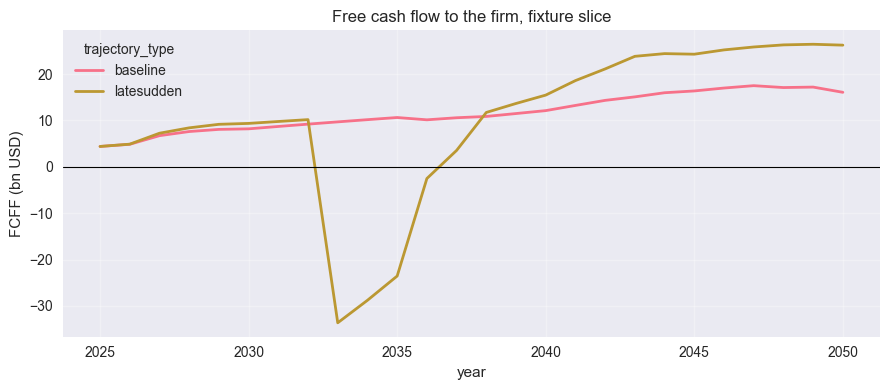

In [9]:
annual = earnings.groupby(["year", "trajectory_type"])["FCFF"].sum().unstack() / 1e9
ax = annual.plot(figsize=(9, 4), lw=2)
ax.set_title("Free cash flow to the firm, fixture slice")
ax.set_ylabel("FCFF (bn USD)")
ax.set_xlabel("year")
ax.axhline(0, color="black", lw=0.8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Checkpoint 5 — valuation (stage 5)

`company_npv.csv` is the headline table: one row per company, the two NPVs, and
`npv_change`.

**Reading the sign of `npv_change`.** It is defined as

```
npv_change = (latesudden_npv - baseline_npv) / abs(baseline_npv)
```

so a *negative* value means the late-and-sudden world is worth less than the
baseline — the transition destroys value for that company. The `abs()` in the
denominator matters: it keeps the sign of the numerator, so a company whose
baseline NPV is already negative still reports a negative change when the shock
makes it worse. Without it, the sign would flip for exactly the companies in the
most trouble.

In [10]:
company_npv = read_output("07_model_output/company_npv.csv").sort_values("npv_change")
company_npv.assign(
    baseline_npv_bn=lambda d: (d["baseline_npv"] / 1e9).round(2),
    latesudden_npv_bn=lambda d: (d["latesudden_npv"] / 1e9).round(2),
    npv_change=lambda d: d["npv_change"].round(3),
)[["company_name", "asset_count", "baseline_npv_bn", "latesudden_npv_bn", "npv_change"]]

,company_name,asset_count,baseline_npv_bn,latesudden_npv_bn,npv_change
0,Asahi Mutual Life Insurance Co,620,0.31,0.16,-0.474
1,Resona Bank Ltd,620,1.04,0.56,-0.459
2,Government of United Arab Emirates,262,71.91,42.56,-0.408
3,ENGIE SA,542,83.28,101.58,0.220
4,Emirate of Abu Dhabi (United Arab Emirates),230,31.11,43.15,0.387


`asset_npv.csv` carries the same comparison one level down, with the cost
components kept alongside so a company result can be traced to the assets
driving it.

One row per (asset, owning company): an asset held by two companies appears
twice, once per owner, each carrying that owner's share.

In [11]:
asset_npv = read_output("07_model_output/asset_npv.csv")
worst = asset_npv.nsmallest(5, "npv_change")
# asset_id / asset_name are omitted on purpose: for synthetic assets the name
# embeds the owning company_id (NEW_<company_id>_<sector>_<technology>), and a
# committed notebook is not a licensed data payload. Read the ids off
# asset_npv.csv in your own run if you need them.
worst[["company_name", "technology", "alignment_type",
       "baseline_npv", "latesudden_npv", "npv_change"]]

,company_name,technology,alignment_type,baseline_npv,latesudden_npv,npv_change
2140,Asahi Mutual Life Insurance Co,SolarCap - CSP,misaligned_low_carbon,0.0,-3.604709e+04,-inf
2172,Resona Bank Ltd,SolarCap - CSP,misaligned_low_carbon,0.0,-1.228878e+05,-inf
2200,Government of United Arab Emirates,SolarCap - CSP,misaligned_low_carbon,0.0,-1.543555e+06,-inf
2226,ENGIE SA,SolarCap - CSP,misaligned_low_carbon,0.0,-1.674473e+06,-inf
2251,Emirate of Abu Dhabi (United Arab Emirates),SolarCap - CSP,misaligned_low_carbon,0.0,-1.543555e+06,-inf


## 3. A parameter experiment

Every knob in the six `conf/base/parameters_*.yml` files can be overridden for a
single run without editing anything — that is what `extra_params` does here, and
`kedro run --params key=value` does on the command line.

### `market_passthrough`

`market_passthrough` is the share of the differential carbon cost a firm can pass
on to customers, from `0.0` (the default: the firm absorbs all of it, the
conservative stress-test assumption) to `1.0` (customers absorb all of it).

In [12]:
baseline_npv = company_npv.set_index("company_name")["latesudden_npv"]

run_altr(market_passthrough=1.0)
passthrough_npv = read_output("07_model_output/company_npv.csv").set_index("company_name")["latesudden_npv"]

comparison = pd.DataFrame({
    "passthrough 0.0 (default)": baseline_npv / 1e9,
    "passthrough 1.0": passthrough_npv / 1e9,
}).sort_values("passthrough 0.0 (default)")
comparison.assign(delta=lambda d: d["passthrough 1.0"] - d["passthrough 0.0 (default)"]).round(2)

,passthrough 0.0 (default),passthrough 1.0,delta
company_name,,,
Asahi Mutual Life Insurance Co,0.16,0.30,0.14
Resona Bank Ltd,0.56,1.02,0.46
Government of United Arab Emirates,42.56,127.09,84.52
Emirate of Abu Dhabi (United Arab Emirates),43.15,70.44,27.28
ENGIE SA,101.58,116.68,15.09


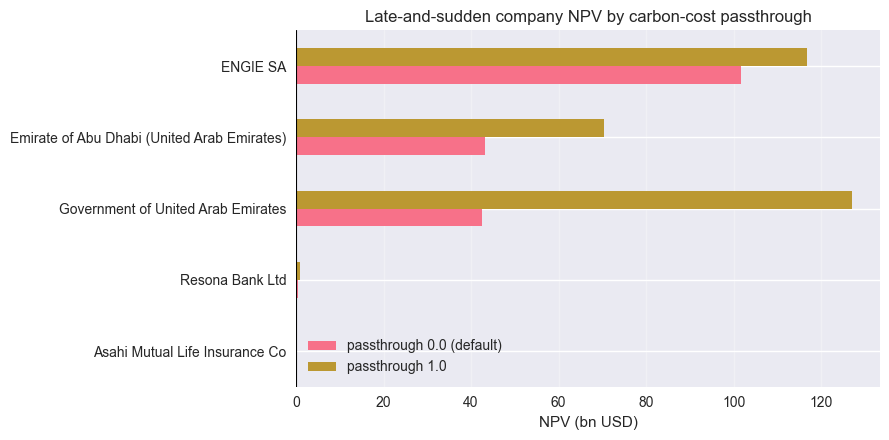

In [13]:
ax = comparison.plot.barh(figsize=(9, 4.5))
ax.set_title("Late-and-sudden company NPV by carbon-cost passthrough")
ax.set_xlabel("NPV (bn USD)")
ax.set_ylabel("")
ax.axvline(0, color="black", lw=0.8)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Letting firms pass the carbon cost through moves every company's valuation in the
same direction, and by an amount that scales with how carbon-intensive its fleet
is. That is the shape you should expect from a knob that works: a consistent sign
and a magnitude you can explain.

Confirm a knob actually moves your numbers before reading meaning into a sweep. A
parameter that gates a value which is later clamped, or one that is only read
when another switch is on, can be completely inert on a given slice — try
`include_replacement_capex` (which does nothing while `replacement_capex_rate`
has no capacity growth to act on) if you want to see that happen.

Other knobs worth a run: `apply_continued_om_shock` (charge fixed O&M on the
first-year capacity of a retiring asset — the mechanism that makes stranding
bite), and `dcf.discount_rate_shock` (the risk premium on the shock pathway).

In [14]:
# Leave data/fixture_run/ holding a default-parameter run, so anything that reads
# those files after this notebook sees the pinned regression numbers.
print(f"restored default run in {run_altr():.1f}s")

restored default run in 18.8s


## Where to go next

- **[Quickstart](../docs/handover/quickstart.md)** — running the model on your
  own inputs rather than the fixture slice.
- **[User guide](../docs/handover/user_guide.md)** — what each output column
  means and how to read a result.
- **[Architecture](../docs/handover/architecture.md)** — the stage map and what
  crosses each boundary.
- **[Parameters reference](../docs/handover/parameters.md)** — every knob, its
  default and its units, generated from the YAML itself.
- **[Troubleshooting](../docs/handover/troubleshooting.md)** — when a run fails.

To run on real data: put the three deliverables files in `data/01_raw/`, run
`uv run python scripts/prepare_inputs.py`, then `uv run kedro run`.